# 2. Diagnostic Analytics

## Why did it happen? (Root Cause Analysis)

## Revenue Performance (Diagnostic)

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

!jupyter nbconvert --to python _Exploratory_Data_Analysis.ipynb
from _Exploratory_Data_Analysis import read_table


[NbConvertApp] Converting notebook _Exploratory_Data_Analysis.ipynb to python
[NbConvertApp] Writing 2951 bytes to _Exploratory_Data_Analysis.py


In [31]:
# Step 1: Yearly revenue (unchanged — revenue only exists where a checkout happened, no gap here)
revenue_by_day = (
    read_table("fact_reservations")[
        read_table("fact_reservations")["booking_status"] == "Checked Out"
    ]
    .groupby(["property_id", "check_in_date_key"])["room_revenue"]
    .sum()
    .reset_index()
)

yearly_revenue = (
    revenue_by_day.merge(
        read_table("dim_date")[["date_key", "year"]],
        left_on="check_in_date_key",
        right_on="date_key",
        how="left"
    )
    
    .groupby("year")["room_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"room_revenue": "total_revenue"})
)

# Step 2: Yearly rooms available — independent, straight from the full inventory table
yearly_rooms_available = (
    read_table("fact_room_inventory")
    .merge(
        read_table("dim_date")[["date_key", "year"]],
        on="date_key",
        how="left"
    )
    .groupby("year")["rooms_available"]
    .sum()
    .reset_index()
    .rename(columns={"rooms_available": "total_rooms_available"})
)

# Step 3: Combine the two year-level aggregates (small frames, no row-explosion risk)
yearly_revpar = yearly_revenue.merge(yearly_rooms_available, on="year", how="inner")

yearly_revpar["RevPAR"] = (
    yearly_revpar["total_revenue"] / yearly_revpar["total_rooms_available"]
)

yearly_revpar["YOY_GROWTH_PCT"] = (
    yearly_revpar["RevPAR"].pct_change() * 100
).round(2)

print(yearly_revpar[["year", "RevPAR", "YOY_GROWTH_PCT"]])


   year     RevPAR  YOY_GROWTH_PCT
0  2023  15.468407             NaN
1  2024  16.113059            4.17
2  2025  16.222089            0.68


ADR = Room revenue /  Room sold

In [32]:
# Step 1 get the revenue by day for checked out reservations.
revenue_by_day = (
    read_table("FACT_RESERVATIONS")[
        read_table("FACT_RESERVATIONS")["booking_status"] == "Checked Out"
    ]
    .groupby(["check_in_date_key", "property_id"])["room_revenue"]
    .sum()
    .reset_index()
)


# Step 2 merge revenue by day to dim_date to get the yearly total_revenue.

yearly_total_revenue = (
    revenue_by_day.merge(
        read_table("dim_date")[["date_key", "year"]],
        how="left",
        left_on=["check_in_date_key"],
        right_on=["date_key"],
    )
    .groupby("year")["room_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"room_revenue": "total_revenue"})
)


# Step 3 merge fact_room_inventory to dim_date to get the total_rooms_sold per year.

yearly_rooms_sold = (
    read_table("fact_room_inventory")
    .merge(read_table("dim_date")[["date_key", "year"]], on="date_key", how="left")
    .groupby("year")["rooms_sold"]
    .sum()
    .reset_index()
    .rename(columns={"rooms_sold": "total_rooms_sold"})
)


# Step 4 merge yearly_total_revenue to yearly_rooms_sold.

yearly_adr = yearly_total_revenue.merge(yearly_rooms_sold, on="year", how="inner")

yearly_adr["adr"] = yearly_adr["total_revenue"] / yearly_adr["total_rooms_sold"]

yearly_adr["YOY_GROWTH_PCT"] = (yearly_adr["adr"].pct_change() * 100).round(2)


print(yearly_adr[["year", "adr", "YOY_GROWTH_PCT"]])





   year        adr  YOY_GROWTH_PCT
0  2023  22.558876             NaN
1  2024  23.488754            4.12
2  2025  23.632108            0.61


### Occupancy

In [33]:
# Occupancy


yearly_metrics = yearly_adr.drop(columns=["total_revenue"]).merge(yearly_revpar, on="year", how="inner")
yearly_metrics['Occupancy'] = (yearly_metrics['total_rooms_sold'] / yearly_metrics['total_rooms_available'] * 100) .round()
yearly_metrics['Occupancy_check'] = (yearly_metrics["RevPAR"] /yearly_metrics["adr"] * 100).round()
print(yearly_metrics[["year", "adr", "RevPAR", "Occupancy","Occupancy_check"]])

   year        adr     RevPAR  Occupancy  Occupancy_check
0  2023  22.558876  15.468407       69.0             69.0
1  2024  23.488754  16.113059       69.0             69.0
2  2025  23.632108  16.222089       69.0             69.0


### Market segment and Booking channel

In [34]:
# market_segment and booking_channel

daily_segment_channel_metrics  = (
    read_table("FACT_RESERVATIONS")[
        read_table("FACT_RESERVATIONS")["booking_status"] == "Checked Out"
    ]
    .groupby(["check_in_date_key", "property_id","market_segment","booking_channel"])
    .agg(
        room_revenue = ("room_revenue","sum"),
        room_nights =("length_of_stay", "sum"),
        booking_count=("booking_channel", "sum") 
    )
    .reset_index()

)

yearly_segment_channel_metrics  = (
    daily_segment_channel_metrics .merge(
        read_table("dim_date")[["date_key", "year"]],
        how="left",
        left_on="check_in_date_key",
        right_on="date_key",
    )
    .groupby(["year", "market_segment","booking_channel"])
    .agg(
        segment_revenue = ("room_revenue","sum"),
        segment_room_nights =("room_nights", "sum"),
    

    )
    .reset_index()
)
yearly_segment_channel_metrics ["segment_adr"] = yearly_segment_channel_metrics ["segment_revenue"] / yearly_segment_channel_metrics  ["segment_room_nights"]
yearly_segment_channel_metrics 

,year,market_segment,booking_channel,segment_revenue,segment_room_nights,segment_adr
0,2023,Corporate,Corporate Travel Desk,12986373.00,34214,379.563132
1,2023,Corporate,GDS - Corporate,9595526.55,24671,388.939506
2,2023,Direct,Property Direct,7167862.50,18799,381.289563
3,2023,Direct,Velora App,4315780.54,11296,382.062725
4,2023,Direct,Velora.com,8318730.38,21867,380.423944
5,2023,Group,Travel Agent,5580498.65,14488,385.180746
6,2023,Leisure,OTA - Booking.com,13318690.65,34467,386.418622
7,2023,Leisure,OTA - Expedia,11525985.86,30353,379.731356
8,2023,Leisure,Property Direct,10765695.96,27979,384.777725
9,2023,Leisure,Travel Agent,5416468.17,13966,387.832462


In [35]:
# add yearly_segment_channel_metrics into yearly_metrics table

yearly_all_metrics = yearly_metrics.merge(
    yearly_segment_channel_metrics ,
    on="year",
    how="left"
)

yearly_all_metrics = yearly_all_metrics.fillna(0)
yearly_all_metrics

,year,total_rooms_sold,adr,YOY_GROWTH_PCT_x,total_revenue,total_rooms_available,RevPAR,YOY_GROWTH_PCT_y,Occupancy,Occupancy_check,market_segment,booking_channel,segment_revenue,segment_room_nights,segment_adr
0,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Corporate,Corporate Travel Desk,12986373.00,34214,379.563132
1,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Corporate,GDS - Corporate,9595526.55,24671,388.939506
2,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Direct,Property Direct,7167862.50,18799,381.289563
3,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Direct,Velora App,4315780.54,11296,382.062725
4,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Direct,Velora.com,8318730.38,21867,380.423944
5,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Group,Travel Agent,5580498.65,14488,385.180746
6,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Leisure,OTA - Booking.com,13318690.65,34467,386.418622
7,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Leisure,OTA - Expedia,11525985.86,30353,379.731356
8,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Leisure,Property Direct,10765695.96,27979,384.777725
9,2023,5269742,22.558876,0.00,1.188795e+08,7685307,15.468407,0.00,69.0,69.0,Leisure,Travel Agent,5416468.17,13966,387.832462


# Visualization  

####  Yearly RevPAR (2023 - 2025)

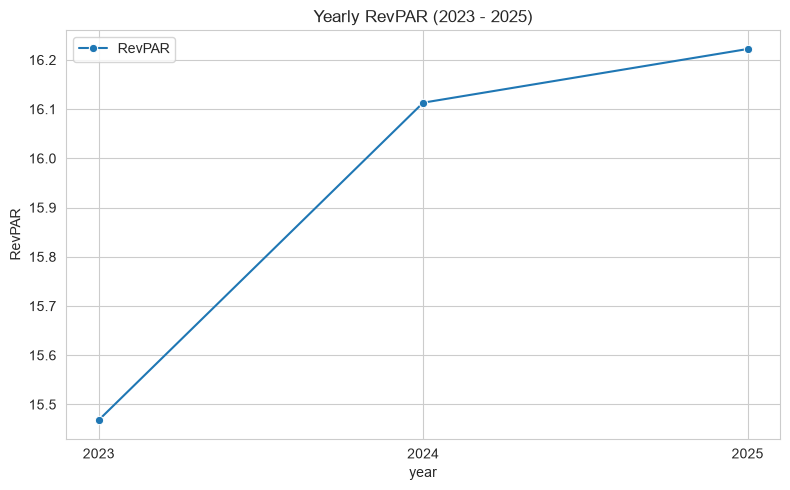

In [36]:
sns.set_style("whitegrid")

fig,ax = plt.subplots(figsize=(8,5))

sns.lineplot(data=yearly_metrics, x="year", y="RevPAR", marker="o", ax=ax, label="RevPAR")
ax.set_title("Yearly RevPAR (2023 - 2025)")
ax.set_xticks(yearly_metrics["year"])
ax.set_ylabel("RevPAR")
plt.tight_layout()
plt.show()

####  Yearly ADR & Occupancy (2023 - 2025)

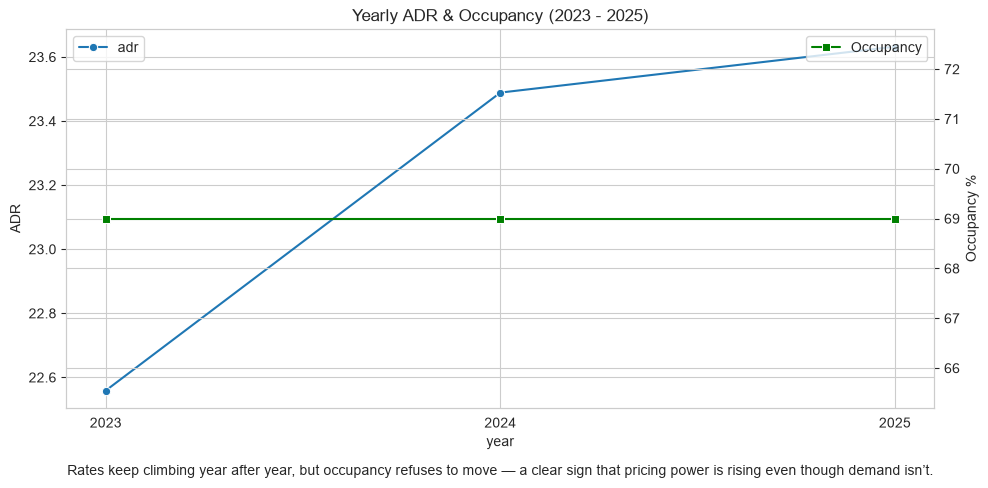

In [37]:
sns.set_style("whitegrid")

fig,ax = plt.subplots(figsize=(10,5))

sns.lineplot(data=yearly_metrics, x="year", y="adr", marker="o", ax=ax, label="adr")
ax.set_ylabel("ADR")


ax2 = ax.twinx()
sns.lineplot(data=yearly_metrics, x="year", y="Occupancy", marker="s", ax=ax2, label="Occupancy", color="green")
ax2.set_ylabel("Occupancy %")



ax.set_title("Yearly ADR & Occupancy (2023 - 2025)")
ax.set_xticks(yearly_metrics["year"])
ax.set_ylabel("ADR")
plt.text(
    0.5, -0.15,
    "Rates keep climbing year after year, but occupancy refuses to move — a clear sign that pricing power is rising even though demand isn’t.",
    transform=ax.transAxes,
    fontsize=10,
    ha="center",
    va="top"
)



plt.tight_layout()
plt.show()




###  Yearly Segment ADR comparison

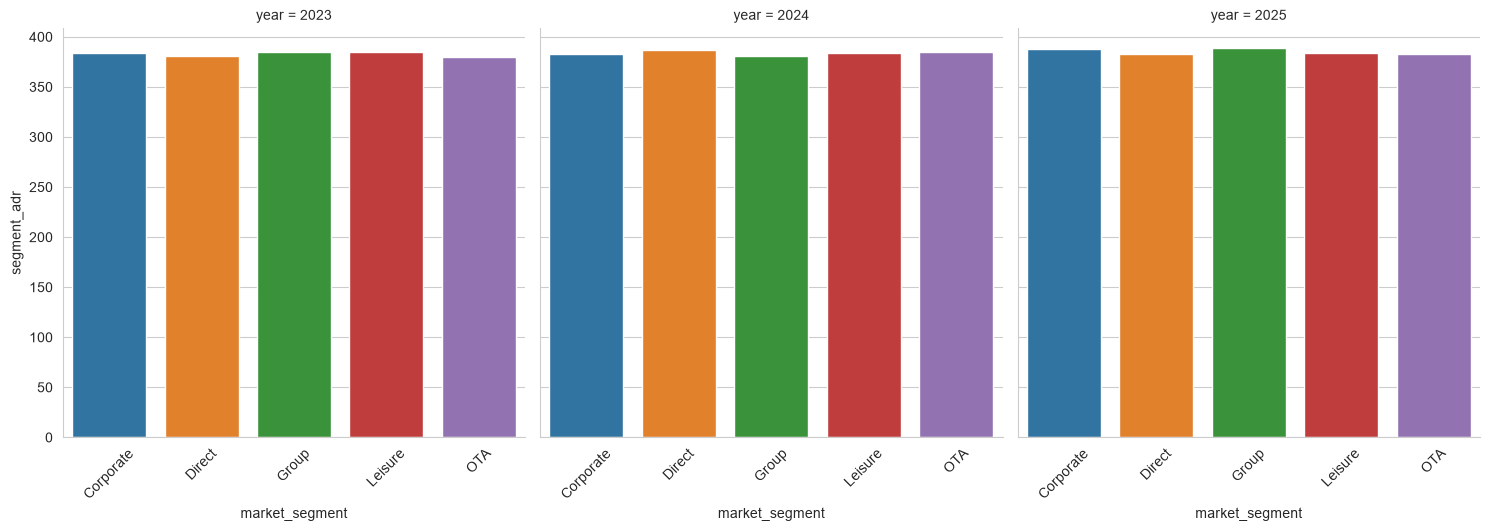

In [53]:
yearly_segment_metrics = (
    yearly_segment_channel_metrics
    .groupby(["year", "market_segment"])
    .agg(
        segment_revenue=("segment_revenue", "sum"),
        segment_room_nights=("segment_room_nights", "sum")
    )
    .reset_index()
)
yearly_segment_metrics["segment_adr"] = (
    yearly_segment_metrics["segment_revenue"] / yearly_segment_metrics["segment_room_nights"]
)

g = sns.catplot(
    data=yearly_segment_metrics, x="market_segment", y="segment_adr",hue="market_segment",
    col="year", kind="bar", order=sorted(yearly_segment_metrics["market_segment"].unique())
)
g.set_xticklabels(rotation=45)

### Revenue mix shift by segment

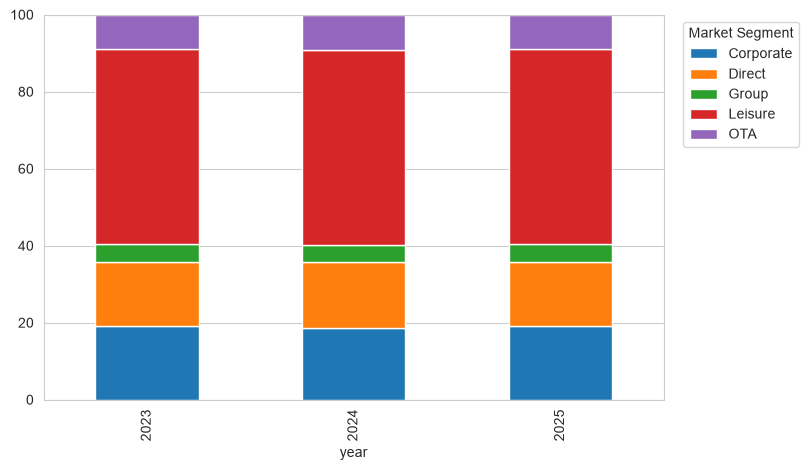

In [39]:
# Step 1: revenue share per year
yearly_segment_metrics["year_total_revenue"] = (
    yearly_segment_metrics.groupby("year")["segment_revenue"].transform("sum")
)
yearly_segment_metrics["revenue_share_pct"] = (
    yearly_segment_metrics["segment_revenue"] / yearly_segment_metrics["year_total_revenue"] * 100
).round(2)


# Step 2: long -> wide
revenue_share_wide = yearly_segment_metrics.pivot(
    index="year", columns="market_segment", values="revenue_share_pct"
)


# Step 3: plot — pandas' own .plot(), not seaborn, since seaborn has no built-in stacked option
fig, ax = plt.subplots(figsize=(8, 5))
revenue_share_wide.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylim(0, 100)
ax.legend(title="Market Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

###  Yearly booking channel ADR comparison

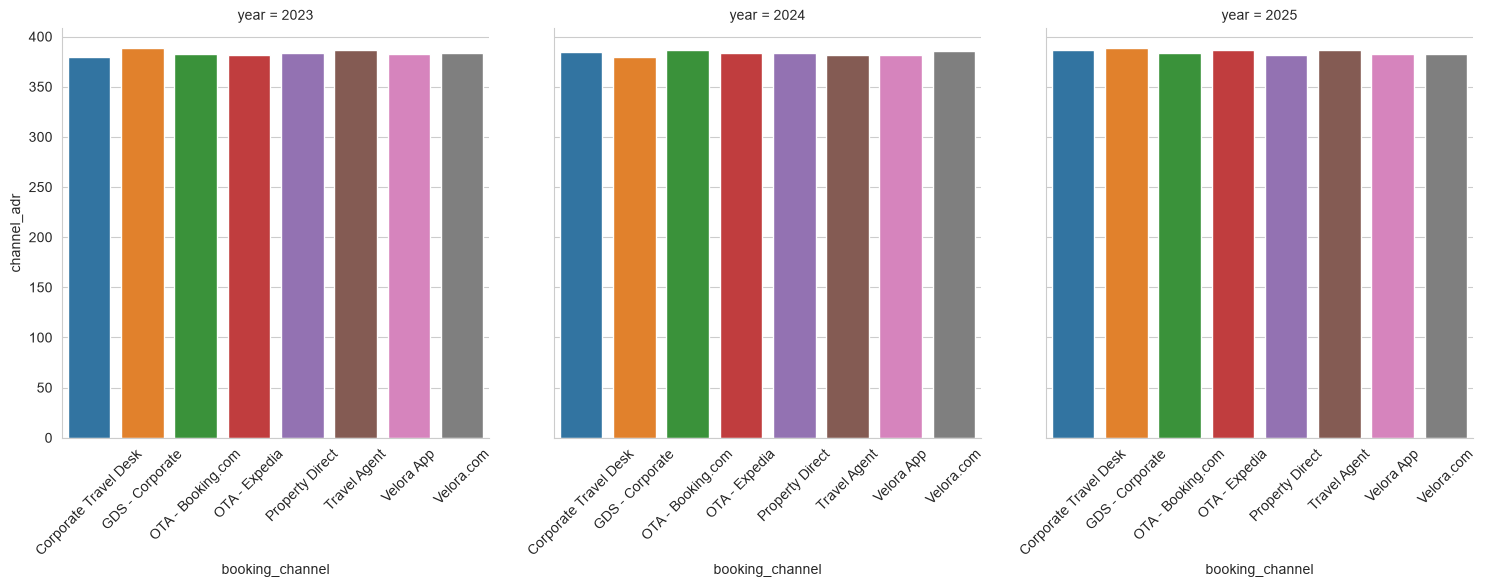

In [40]:
yearly_channel_metrics = (
    yearly_segment_channel_metrics
    .groupby(["year", "booking_channel"])
    .agg(
        segment_revenue=("segment_revenue", "sum"),
        segment_room_nights=("segment_room_nights", "sum")
    )
    .reset_index()
)
yearly_channel_metrics["channel_adr"] = (
    yearly_channel_metrics["segment_revenue"] / yearly_channel_metrics["segment_room_nights"]
)

g = sns.catplot(
    data=yearly_channel_metrics, x="booking_channel", y="channel_adr",hue="booking_channel",
    col="year", kind="bar", order=sorted(yearly_channel_metrics["booking_channel"].unique())
)
g.set_xticklabels(rotation=45)

### Booking channel mix shift by segment

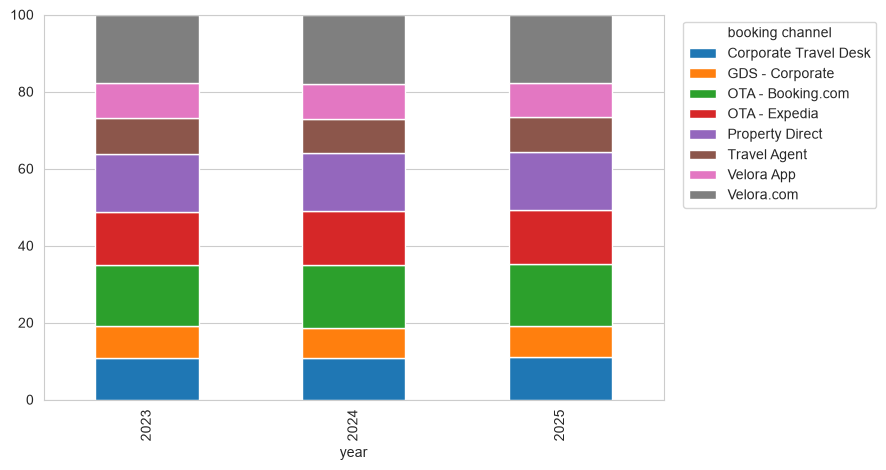

In [50]:
# Step 1: revenue share per year
yearly_channel_metrics["year_total_revenue"] = (
    yearly_channel_metrics.groupby("year")["segment_revenue"].transform("sum")
)

yearly_channel_metrics["revenue_share_pct"] = (
    yearly_channel_metrics["segment_revenue"] / yearly_channel_metrics["year_total_revenue"] * 100
).round(2)


# Step 2: long -> wide
revenue_share_wide = yearly_channel_metrics.pivot(
    index="year", columns="booking_channel", values="revenue_share_pct"
)


# Step 3: plot — pandas' own .plot(), not seaborn, since seaborn has no built-in stacked option
fig, ax = plt.subplots(figsize=(8, 5))
revenue_share_wide.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylim(0, 100)
ax.legend(title="booking channel", bbox_to_anchor=(1.02, 1), loc="upper left")